# Country Clustering using K-Means (Unsupervised Learning)

**Goal:** HELP International has raised ~$10 million and wants to know which countries need aid the most, based on socio-economic and health factors. We use K-Means clustering to group countries and identify the ones most in need of help.

**End-to-end pipeline:** Load data -> Understand data -> Clean data -> EDA -> Feature selection -> Feature scaling -> Find best K -> Train K-Means -> Evaluate/Interpret clusters -> Save trained model (.pkl) -> Reload model & run inference on new/sample data.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import pickle
import joblib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 2. Load Dataset

The original notebook loaded the data via `kagglehub` from the Kaggle dataset
`rohan0301/unsupervised-learning-on-country-data`. To make this notebook run anywhere
(no Kaggle auth needed), we load the same `Country-data.csv` file from disk.
If you prefer, uncomment the kagglehub block below.

In [2]:
# --- Option A (used here): load from local CSV file ---
df = pd.read_csv("Country-data.csv")

# --- Option B: load directly from Kaggle (requires kagglehub + Kaggle credentials) ---
# import kagglehub
# from kagglehub import KaggleDatasetAdapter
# df = kagglehub.load_dataset(
#     KaggleDatasetAdapter.PANDAS,
#     "rohan0301/unsupervised-learning-on-country-data",
#     "Country-data.csv",
# )

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Understand the Dataset
Check shape, columns, data types, missing values, duplicate values and statistical summary.

In [3]:
df.shape

(167, 10)

In [4]:
df.dtypes

country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [5]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

In [6]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


## 4. Data Cleaning

This dataset is already very clean (no missing values, no duplicates, correct data types
as confirmed above), so no imputation or type-conversion is required.
No feature engineering is needed either, since this is an unsupervised learning
(clustering) problem, not a supervised prediction problem.

In [10]:
assert df.isnull().sum().sum() == 0, "Dataset has missing values"
assert df.duplicated().sum() == 0, "Dataset has duplicate rows"
print("Data is clean: no missing values, no duplicate rows.")


Data is clean: no missing values, no duplicate rows.


## 5. Basic EDA

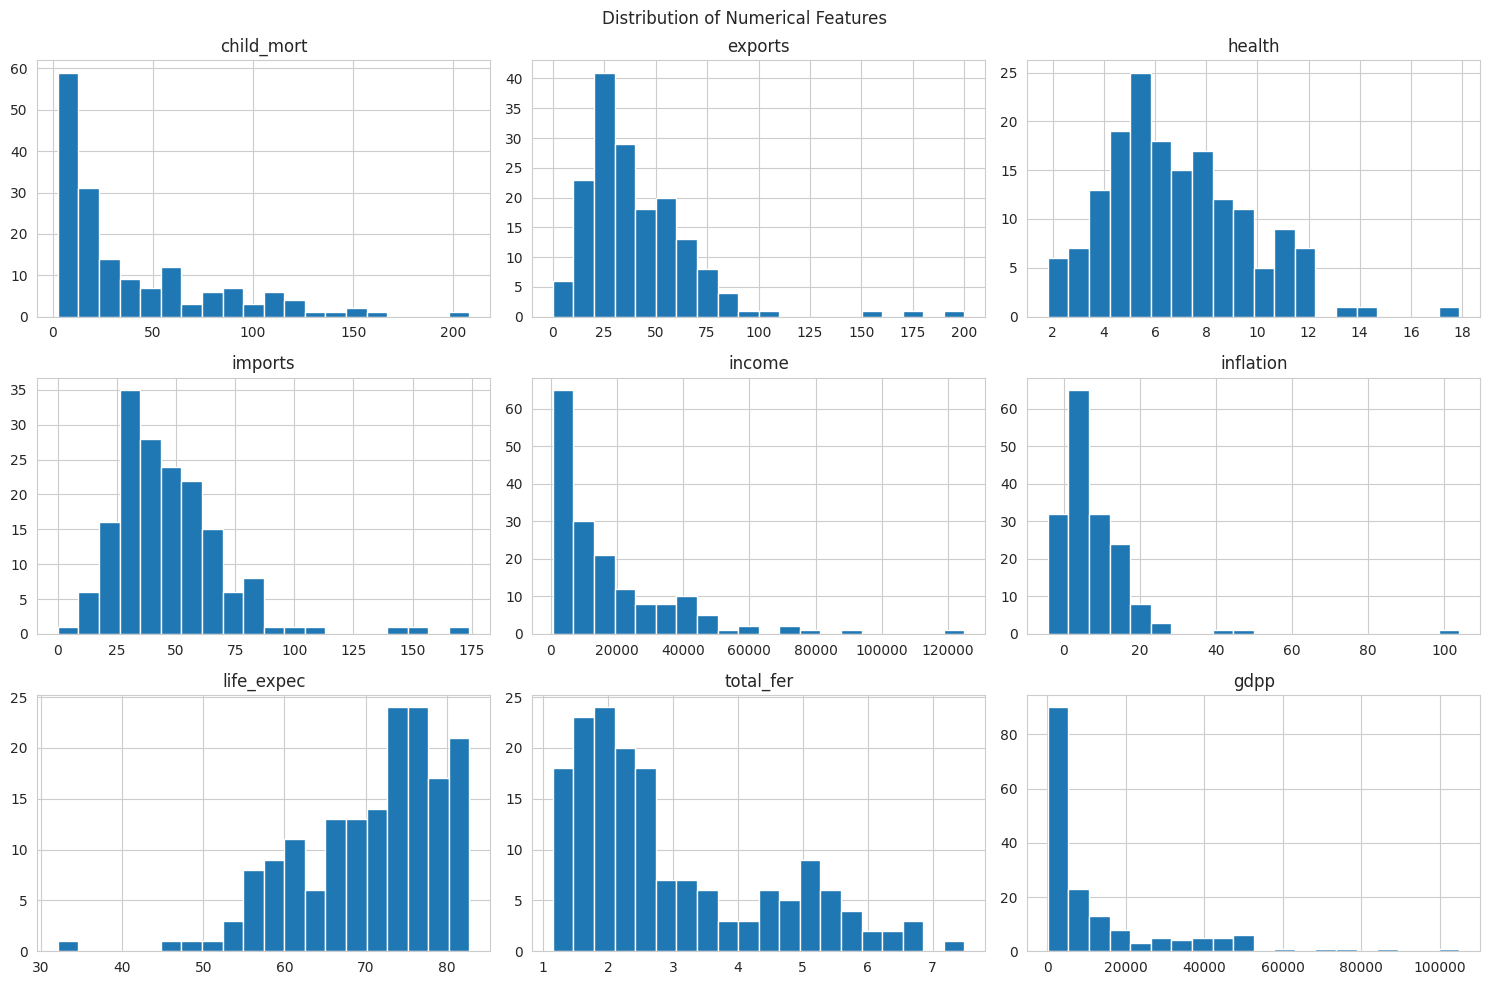

In [11]:
# Numerical distribution of all features
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


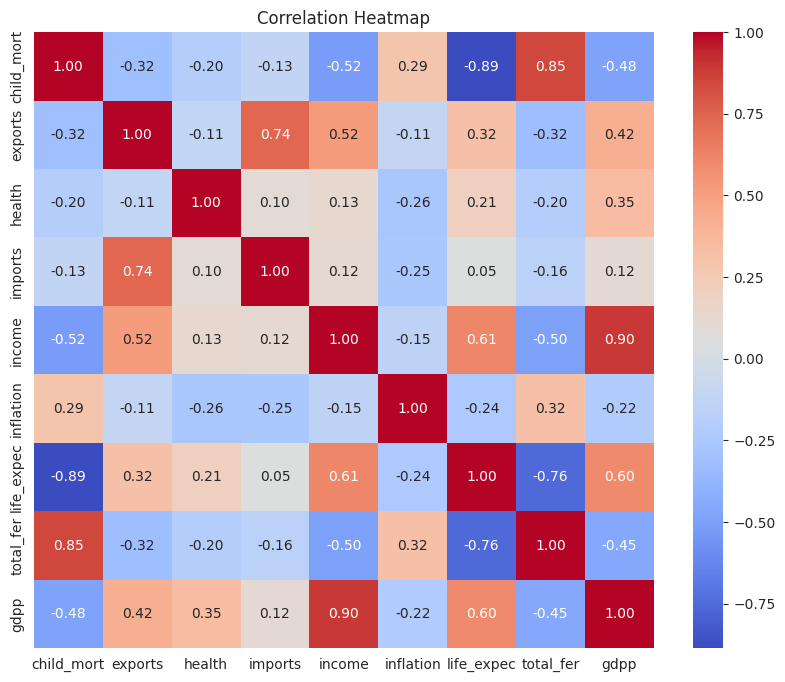

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


In [13]:
# Top 10 Highest Income Countries
df.sort_values(by='income', ascending=False).head(10)[['country', 'income']]


,country,income
123,Qatar,125000
91,Luxembourg,91700
23,Brunei,80600
82,Kuwait,75200
133,Singapore,72100
114,Norway,62300
157,United Arab Emirates,57600
145,Switzerland,55500
159,United States,49400
73,Ireland,45700


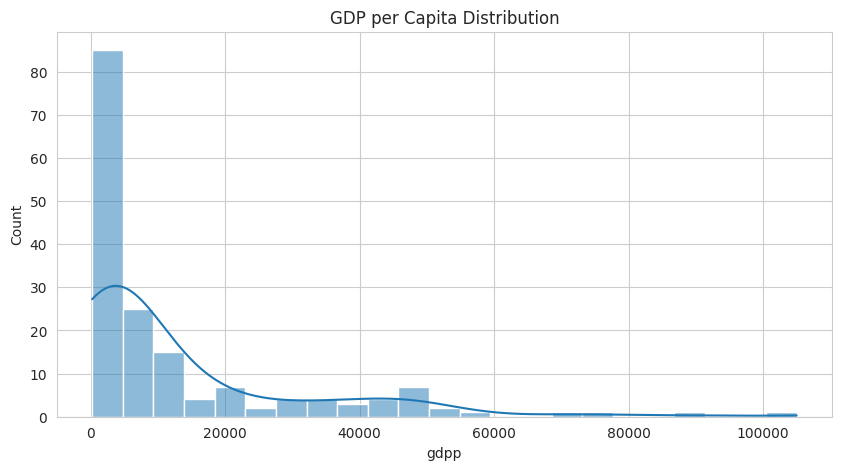

,country,gdpp
91,Luxembourg,105000
114,Norway,87800
145,Switzerland,74600
123,Qatar,70300
44,Denmark,58000
144,Sweden,52100
7,Australia,51900
110,Netherlands,50300
73,Ireland,48700
159,United States,48400


In [14]:
# GDP per capita distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['gdpp'], kde=True)
plt.title("GDP per Capita Distribution")
plt.show()

df[['country', 'gdpp']].sort_values(by='gdpp', ascending=False).head(10)


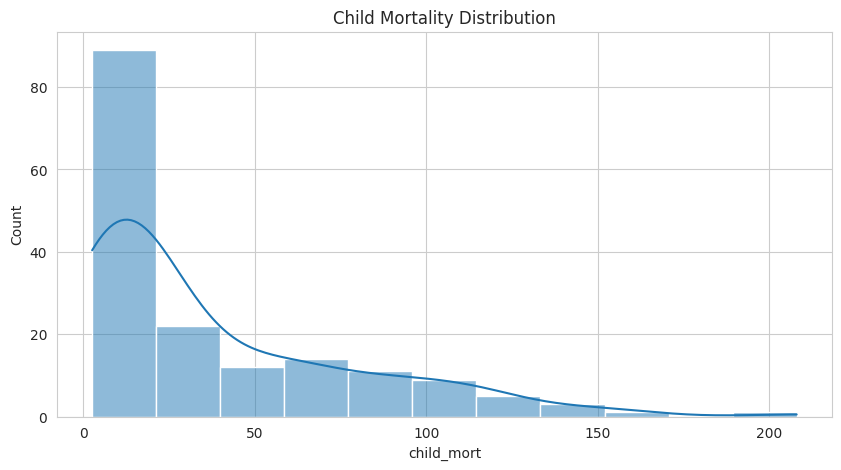

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0
113,Nigeria,130.0
112,Niger,123.0
3,Angola,119.0
25,Burkina Faso,116.0
37,"Congo, Dem. Rep.",116.0


In [15]:
# Child Mortality distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['child_mort'], kde=True)
plt.title("Child Mortality Distribution")
plt.show()

df[['country', 'child_mort']].sort_values(by='child_mort', ascending=False).head(10)


## 6. Feature Selection

`country` cannot be used as a model feature - it is just a text identifier, and K-Means
(like all standard ML algorithms) can only learn from numerical values. All 9 remaining
numeric columns are used as features.

In [16]:
feature_cols = [c for c in df.columns if c != 'country']
X_raw = df[feature_cols].copy()
print("Features used:", feature_cols)
X_raw.head()


Features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 7. Feature Scaling

K-Means is a **distance-based** algorithm (it uses Euclidean distance to assign points
to the nearest centroid). Features like `income` and `gdpp` are on a much larger scale
than features like `total_fer`, so without scaling those large-scale features would
dominate the distance calculation. We use `StandardScaler` to standardize every feature
to mean 0 and standard deviation 1.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 8. Finding the Best K (Elbow Method + Silhouette Score)

We try K from 2 to 10 and look at:
- **WCSS / inertia** (Elbow Method): total within-cluster sum of squares - look for the "elbow" where it stops dropping sharply.
- **Silhouette Score**: measures how well separated the clusters are (higher is better, range -1 to 1).

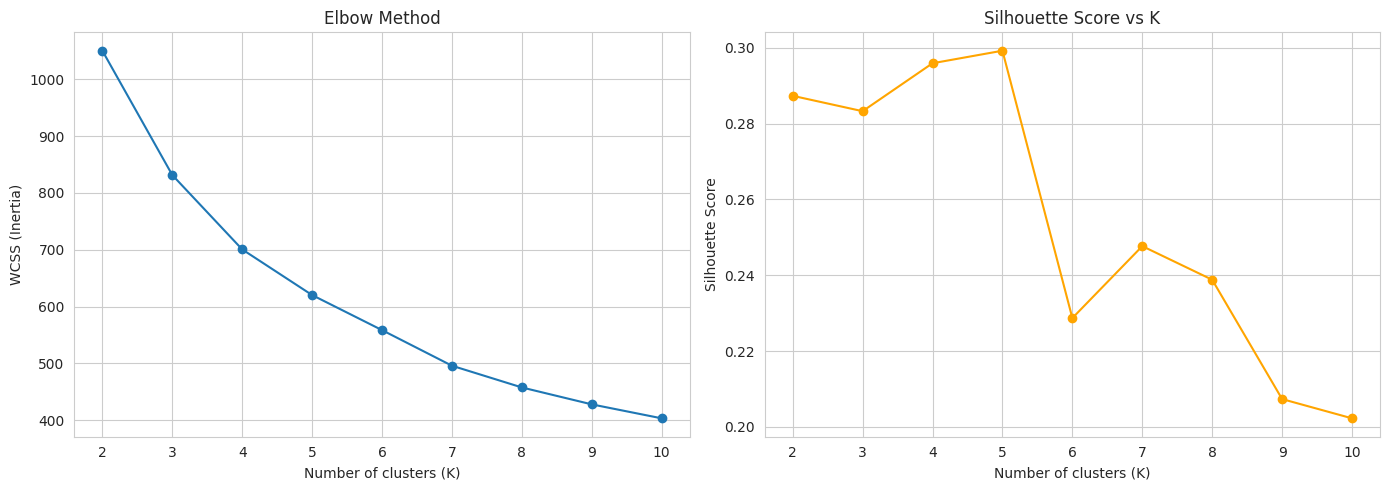

K=2: silhouette_score=0.2874
K=3: silhouette_score=0.2833
K=4: silhouette_score=0.2960
K=5: silhouette_score=0.2993
K=6: silhouette_score=0.2287
K=7: silhouette_score=0.2477
K=8: silhouette_score=0.2388
K=9: silhouette_score=0.2073
K=10: silhouette_score=0.2022


In [18]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), wcss, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")

axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"K={k}: silhouette_score={s:.4f}")


In [19]:
# Best K chosen using elbow point + highest silhouette score.
# For this dataset K=3 gives a clean, interpretable split
# (Developed / Developing / Under-developed countries).
BEST_K = 3
print("Chosen number of clusters:", BEST_K)


Chosen number of clusters: 3


## 9. Train the Final K-Means Model

In [20]:
kmeans_model = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_model.fit_predict(X_scaled)

df['cluster'] = cluster_labels
print("Cluster counts:")
print(df['cluster'].value_counts().sort_index())
df.head()


Cluster counts:
cluster
0    36
1    47
2    84
Name: count, dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


## 10. Test & Interpret the K-Means Model

In [21]:
# Overall model quality
sil = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for K={BEST_K}: {sil:.4f}")


Silhouette Score for K=3: 0.2833


In [22]:
# Cluster centers in ORIGINAL (unscaled) units - easy to interpret
centers_original = scaler.inverse_transform(kmeans_model.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=feature_cols)
centers_df.index.name = 'cluster'
centers_df


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [23]:
# Average feature values per cluster (sanity check vs. cluster centers above)
cluster_profile = df.groupby('cluster')[feature_cols].mean()
cluster_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


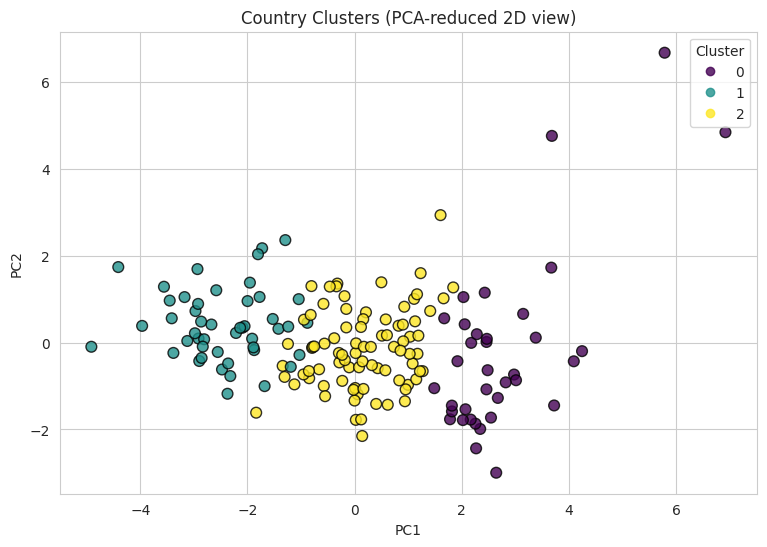

In [24]:
# Visualize clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=60, edgecolor='k', alpha=0.8)
plt.title("Country Clusters (PCA-reduced 2D view)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


In [25]:
# Give each cluster a human-readable label based on child_mort / income / gdpp
# Lower income & gdpp + higher child_mort  -> needs the most help.
rank = cluster_profile['gdpp'].sort_values().index  # ascending gdpp = least developed first
label_map = {
    rank[0]: 'Under-Developed (Needs Aid Most)',
    rank[1]: 'Developing',
    rank[2]: 'Developed',
}
df['development_category'] = df['cluster'].map(label_map)
print(label_map)
df[['country', 'child_mort', 'income', 'gdpp', 'cluster', 'development_category']].head(10)


{np.int32(1): 'Under-Developed (Needs Aid Most)', np.int32(2): 'Developing', np.int32(0): 'Developed'}


,country,child_mort,income,gdpp,cluster,development_category
0,Afghanistan,90.2,1610,553,1,Under-Developed (Needs Aid Most)
1,Albania,16.6,9930,4090,2,Developing
2,Algeria,27.3,12900,4460,2,Developing
3,Angola,119.0,5900,3530,1,Under-Developed (Needs Aid Most)
4,Antigua and Barbuda,10.3,19100,12200,2,Developing
5,Argentina,14.5,18700,10300,2,Developing
6,Armenia,18.1,6700,3220,2,Developing
7,Australia,4.8,41400,51900,0,Developed
8,Austria,4.3,43200,46900,0,Developed
9,Azerbaijan,39.2,16000,5840,2,Developing


In [26]:
# Top 10 countries most in need of aid
df[df['development_category'] == label_map[rank[0]]] \
    .sort_values(by='gdpp') \
    [['country', 'child_mort', 'income', 'gdpp', 'development_category']] \
    .head(10)


,country,child_mort,income,gdpp,development_category
26,Burundi,93.6,764,231,Under-Developed (Needs Aid Most)
88,Liberia,89.3,700,327,Under-Developed (Needs Aid Most)
37,"Congo, Dem. Rep.",116.0,609,334,Under-Developed (Needs Aid Most)
112,Niger,123.0,814,348,Under-Developed (Needs Aid Most)
132,Sierra Leone,160.0,1220,399,Under-Developed (Needs Aid Most)
93,Madagascar,62.2,1390,413,Under-Developed (Needs Aid Most)
106,Mozambique,101.0,918,419,Under-Developed (Needs Aid Most)
31,Central African Republic,149.0,888,446,Under-Developed (Needs Aid Most)
94,Malawi,90.5,1030,459,Under-Developed (Needs Aid Most)
50,Eritrea,55.2,1420,482,Under-Developed (Needs Aid Most)


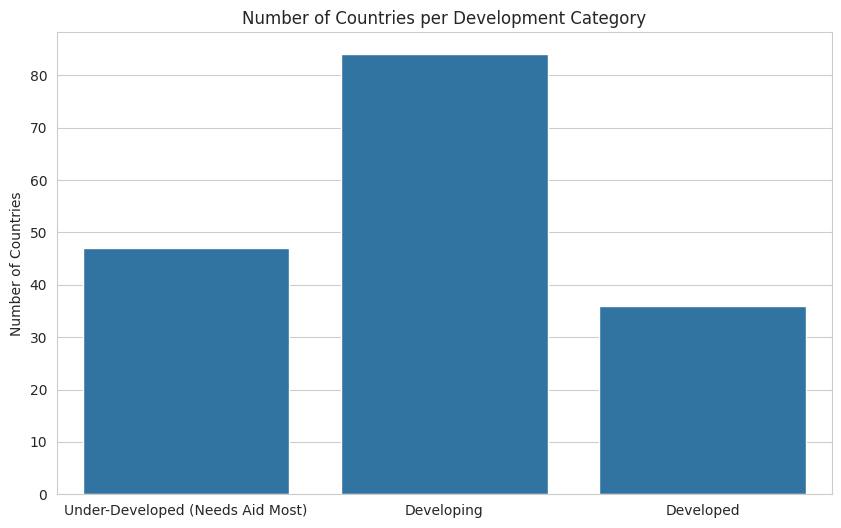

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='development_category', order=[label_map[r] for r in rank])
plt.title("Number of Countries per Development Category")
plt.xlabel("")
plt.ylabel("Number of Countries")
plt.show()


## 11. Save the Trained Model (.pkl)

We save **both** the fitted `KMeans` model and the `StandardScaler` (scaling must be
applied identically at inference time). We use `pickle` for a single combined artifact,
which is the most portable way to ship a "proper" model file.

In [28]:
model_bundle = {
    'model': kmeans_model,
    'scaler': scaler,
    'feature_columns': feature_cols,
    'cluster_label_map': label_map,
}

with open('kmeans_country_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

# Also save with joblib (common alternative, often faster for sklearn models with big arrays)
joblib.dump(model_bundle, 'kmeans_country_model.joblib')

print("Saved: kmeans_country_model.pkl")
print("Saved: kmeans_country_model.joblib")


Saved: kmeans_country_model.pkl
Saved: kmeans_country_model.joblib


## 12. Reload the Saved Model and Run Inference

This simulates how the `.pkl` file would be used in production: load it once, then
predict the cluster/development-category for new country data.

In [29]:
with open('kmeans_country_model.pkl', 'rb') as f:
    loaded_bundle = pickle.load(f)

loaded_model = loaded_bundle['model']
loaded_scaler = loaded_bundle['scaler']
loaded_features = loaded_bundle['feature_columns']
loaded_label_map = loaded_bundle['cluster_label_map']

def predict_country_cluster(sample_dict):
    """sample_dict: dict with the 9 feature values for one country."""
    sample_df = pd.DataFrame([sample_dict])[loaded_features]
    sample_scaled = loaded_scaler.transform(sample_df)
    cluster = loaded_model.predict(sample_scaled)[0]
    category = loaded_label_map[cluster]
    return cluster, category

# Example: predict on the first row of the original data
sample = X_raw.iloc[0].to_dict()
cluster, category = predict_country_cluster(sample)
print("Sample country:", df.iloc[0]['country'])
print("Predicted cluster:", cluster)
print("Predicted development category:", category)


Sample country: Afghanistan
Predicted cluster: 1
Predicted development category: Under-Developed (Needs Aid Most)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [30]:
# Try a made-up low-income, high child-mortality country
new_country = {
    'child_mort': 110.0,
    'exports': 15.0,
    'health': 4.0,
    'imports': 40.0,
    'income': 1500,
    'inflation': 12.0,
    'life_expec': 55.0,
    'total_fer': 5.5,
    'gdpp': 600,
}
cluster, category = predict_country_cluster(new_country)
print("Predicted cluster:", cluster)
print("Predicted development category:", category)


Predicted cluster: 1
Predicted development category: Under-Developed (Needs Aid Most)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


## Summary

- Data was clean (no missing values / duplicates), so no cleaning was needed.
- 9 numeric socio-economic & health features were scaled with `StandardScaler`.
- The Elbow Method + Silhouette Score both support **K=3** clusters.
- Clusters were mapped to human-readable categories: *Under-Developed*, *Developing*, *Developed*, using average `gdpp`/`income`/`child_mort`.
- The final model (KMeans + scaler + metadata) was saved to **`kmeans_country_model.pkl`** (and `.joblib`), and successfully reloaded to run predictions on new data.